# HW1 - Dependency network of *whale* in *Moby-Dick*

**Course:** Linguistic Data: Quantitative Analysis and Visualisation
**Text:** Herman Melville, *Moby-Dick; or, The Whale* (1851), plain-text edition from Project Gutenberg (as distributed with the NLTK Gutenberg corpus), about 260,000 tokens.
**Tools:** spaCy `en_core_web_sm` (tokenization, lemmatization, dependency parsing), NetworkX (graph construction and analysis), Matplotlib (plots).

| Task | Section |
|---|---|
| 1. Choose a novel | Section 1 |
| 2. Lemmatize the novel (1 pt) | Section 2 |
| 3. Extract children and grandchildren of a frequent word (2 pt) | Section 3 |
| 4. Draw the graph and justify the visual parameters (2 pt) | Section 4 |
| 5. Network analysis (2 pt) | Section 5 |
| 6. Conclusions (1 pt) | Section 6 |

In [1]:
import re, collections, math
import spacy
from spacy import displacy
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms import community as nx_comm

pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.family": "DejaVu Sans",
                     "axes.spines.top": False, "axes.spines.right": False})

# Chart colours (one shared palette for all figures)
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURFACE = "#fcfcfb"
LEVEL_COLORS = {0: "#0d366b", 1: "#3987e5", 2: "#b7d3f6"}   # sequential blue: centre -> 1st -> 2nd order
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER = "#c3c2b7"
print("spaCy", spacy.__version__, "| networkx", nx.__version__)

spaCy 3.8.16 | networkx 3.6.1


## 1. The novel

I chose *Moby-Dick* because it is long (135 chapters, more than 200,000 words) and has an obvious "theme word", **whale**. The novel is also an encyclopaedia of whales (the *Cetology* chapters), so the word appears in many syntactic contexts: as a hunted object, as a species name (*sperm whale*, *right whale*), and as a character (*the White Whale*).

In [2]:
raw = open("data/moby_dick.txt", encoding="utf-8").read()
# Split into paragraphs and normalise the hard line-wraps of the Gutenberg file
paragraphs = [re.sub(r"\s+", " ", p).strip() for p in re.split(r"\n\s*\n", raw) if p.strip()]
print(f"{len(raw):,} characters, {len(paragraphs):,} paragraphs")
print(paragraphs[100][:300])

1,220,066 characters, 2,793 paragraphs
Once more. Say you are in the country; in some high land of lakes. Take almost any path you please, and ten to one it carries you down in a dale, and leaves you there by a pool in the stream. There is magic in it. Let the most absent-minded of men be plunged in his deepest reveries--stand that man o


## 2. Lemmatization (1 pt)

spaCy's English pipeline tags every token and looks up its lemma with a rule- and lookup-based lemmatizer that uses the POS tag. The same pass also produces the **dependency parse** needed in Section 3, so the novel is processed only once. NER is switched off because it is not needed.

The lemmatized novel is saved to `data/moby_dick_lemmatized.txt`: one paragraph per line, lemmas in lower case, separated by spaces, with punctuation kept as its own token.

In [3]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])
docs = list(nlp.pipe(paragraphs, batch_size=64))
n_tokens = sum(len(d) for d in docs)
print(f"{n_tokens:,} tokens parsed")

with open("data/moby_dick_lemmatized.txt", "w", encoding="utf-8") as f:
    for d in docs:
        f.write(" ".join(t.lemma_.lower() for t in d if not t.is_space) + "\n")

# Examples: original vs lemmatized
for d in docs[1000:1002]:
    print("ORIG :", d.text[:160])
    print("LEMMA:", " ".join(t.lemma_.lower() for t in d)[:160], "\n")

258,411 tokens parsed
ORIG : So far as what there may be of a narrative in this book; and, indeed, as indirectly touching one or two very interesting and curious particulars in the habits o
LEMMA: so far as what there may be of a narrative in this book ; and , indeed , as indirectly touch one or two very interesting and curious particular in the habit of  

ORIG : I care not to perform this part of my task methodically; but shall be content to produce the desired impression by separate citations of items, practically or r
LEMMA: i care not to perform this part of my task methodically ; but shall be content to produce the desire impression by separate citation of item , practically or re 



### Choosing the word

I count lemma frequencies, leaving out stop words and punctuation. **whale** is the most frequent content lemma in the whole novel, almost twice as frequent as the next one (*man*). That makes it the natural "common word for this novel".

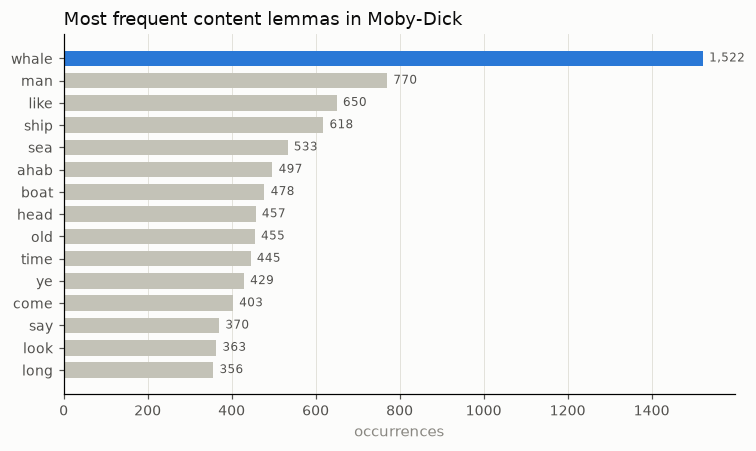

In [4]:
freq = collections.Counter(t.lemma_.lower() for d in docs for t in d
                           if t.is_alpha and not t.is_stop)
top = pd.DataFrame(freq.most_common(15), columns=["lemma", "count"])

fig, ax = plt.subplots(figsize=(7, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
colors = [CATEGORICAL[0] if l == "whale" else OTHER for l in top.lemma]
ax.barh(top.lemma[::-1], top["count"][::-1], color=colors[::-1], height=0.7)
for y, (l, c) in enumerate(zip(top.lemma[::-1], top["count"][::-1])):
    ax.text(c + 15, y, f"{c:,}", va="center", fontsize=8, color=INK2)
ax.set_title("Most frequent content lemmas in Moby-Dick", loc="left", color=INK, fontsize=12)
ax.set_xlabel("occurrences", color=MUTED); ax.tick_params(colors=INK2, labelsize=9)
ax.xaxis.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("figures/01_top_lemmas.png", facecolor=SURFACE); plt.show()

## 3. Children and grandchildren of *whale* (2 pt)

For every token whose lemma is `whale` I take

* its **children**, the direct syntactic dependents (1st-order: *the* **whale**, *sperm* **whale**, **whale** *'s*, ...), and
* the **children of those children** (2nd-order dependents: e.g. **whale** → *of* → *magnitude*).

Punctuation and whitespace tokens are skipped, because a comma attached to a noun says nothing about the noun's syntax. Each relation is stored with its dependency label so it can be aggregated and inspected.

In [5]:
CENTER = "whale"
def keep(tok):
    return not (tok.is_punct or tok.is_space)

rows = []     # one row per extracted dependency
for d in docs:
    for t in d:
        if t.lemma_.lower() != CENTER:
            continue
        for ch in t.children:
            if not keep(ch):
                continue
            rows.append(dict(level=1, head=CENTER, dep=ch.lemma_.lower(), rel=ch.dep_, pos=ch.pos_, stop=ch.is_stop))
            for gc in ch.children:
                if keep(gc):
                    rows.append(dict(level=2, head=ch.lemma_.lower(), dep=gc.lemma_.lower(),
                                     rel=gc.dep_, pos=gc.pos_, stop=gc.is_stop))

deps = pd.DataFrame(rows)
deps.to_csv("data/whale_dependencies.csv", index=False)
n_whale = sum(1 for d in docs for t in d if t.lemma_.lower() == CENTER)
print(f"'{CENTER}' occurs {n_whale:,} times")
print(deps.groupby("level").agg(relations=("dep", "size"), distinct_lemmas=("dep", "nunique")))

'whale' occurs 1,522 times
       relations  distinct_lemmas
level                            
1           2332              426
2            627              315


Here is one sentence from the novel visualised with `displacy`, as in class. The arrows that start at *whale* are its children (1st order); the arrows that start at those children are the grandchildren (2nd order).

In [6]:
# a short, ordinary sentence where 'whale' has a prepositional child with its own object (2 levels)
example = next(s for d in docs for s in d.sents
               if 8 <= len(s) <= 16 and not s.text.isupper() and any(
                   t.lemma_.lower() == CENTER and any(c.dep_ == "prep" and any(g.dep_ == "pobj" for g in c.children)
                                                      for c in t.children) for t in s))
print(example.text)
for t in example:
    if t.lemma_.lower() == CENTER:
        for ch in t.children:
            if keep(ch):
                print(f"  child: {ch.text:<10} ({ch.dep_})  -> grandchildren: {[g.text for g in ch.children if keep(g)]}")
displacy.render(example.as_doc(), style="dep", jupyter=True, options={"compact": True, "distance": 95})

"Whales in the sea God's voice obey."
  child: in         (prep)  -> grandchildren: ['sea']
  child: obey       (appos)  -> grandchildren: ['God', 'voice']


In [7]:
print("Most frequent 1st-order dependents (children):")
display(deps[deps.level == 1].groupby(["dep"]).size().sort_values(ascending=False).head(15).to_frame("count").T)
print("Most frequent 2nd-order edges (child -> grandchild):")
display(deps[deps.level == 2].groupby(["head", "dep"]).size().sort_values(ascending=False).head(15).to_frame("count").T)

Most frequent 1st-order dependents (children):


dep,the,sperm,a,'s,white,right,whale,this,and,great,greenland,in,of,that,other
count,777,187,153,123,104,54,37,33,29,27,19,19,18,15,13


Most frequent 2nd-order edges (child -> grandchild):


head  whale                    of  bone greenland whale  in dick     whale  \
dep     the whale right magnitude whale        or   and sea moby greenland   
count    27    15     4         3     3         3     3   3    2         2   

head  pursue  head      pursue    in  
dep     long white grey   have ocean  
count      2     2    2      2     2

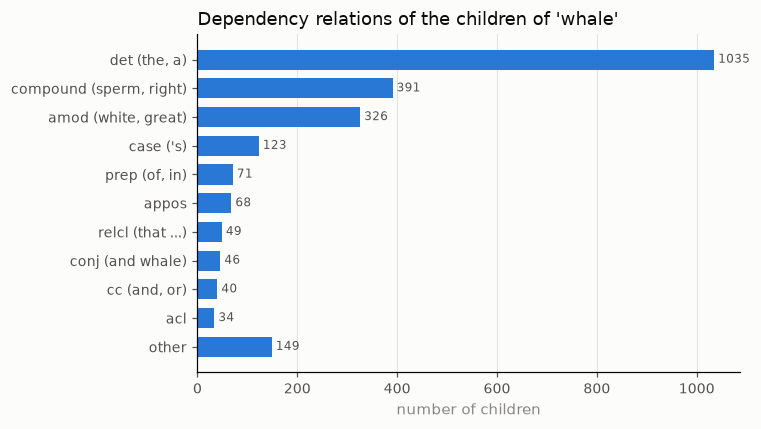

In [8]:
# What kinds of syntactic relations does 'whale' govern?
rel = deps[deps.level == 1].rel.value_counts()
rel = pd.concat([rel.head(10), pd.Series({"other": rel.iloc[10:].sum()})])
labels = {"det": "det (the, a)", "compound": "compound (sperm, right)", "amod": "amod (white, great)",
          "case": "case ('s)", "prep": "prep (of, in)", "appos": "appos", "relcl": "relcl (that ...)",
          "conj": "conj (and whale)", "cc": "cc (and, or)", "acl": "acl"}
fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE); ax.set_facecolor(SURFACE)
ax.barh([labels.get(i, i) for i in rel.index[::-1]], rel.values[::-1], color=CATEGORICAL[0], height=0.7)
for y, v in enumerate(rel.values[::-1]):
    ax.text(v + 8, y, str(v), va="center", fontsize=8, color=INK2)
ax.set_title("Dependency relations of the children of 'whale'", loc="left", color=INK, fontsize=12)
ax.set_xlabel("number of children", color=MUTED); ax.tick_params(colors=INK2, labelsize=9)
ax.xaxis.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("figures/02_relations.png", facecolor=SURFACE); plt.show()

## 4. The graph (2 pt)

### Building the graph

* **Nodes** are lemmas. *whale* is the centre, its children are 1st-order nodes and their children are 2nd-order nodes. A lemma that occurs at both levels is one node, placed at the level closest to the centre.
* **Edges** go from head to dependent (`head → child`). If the same pair occurs several times, the edge gets a `weight` equal to the number of occurrences.
* Self-loops (*whale → whale*, from coordinations like *whale and whale*) are dropped. They carry no network information.

I build two graphs:

1. **Full graph**: every extracted relation. Used for the quantitative analysis in Section 5.
2. **Content graph**, used for the picture. Determiners, pronouns, the possessive *'s*, auxiliaries, particles and archaic pronouns (*thou, ye*) are removed. Determiners and *'s* alone are more than 40% of all children of *whale*, and they would turn the picture into a hairball around *the*. Prepositions and conjunctions are **kept**, because they link *whale* to its 2nd-order context (*whale → of → magnitude*). To keep the picture readable, I keep only children seen at least 3 times, together with all of their own content dependents.

### Visual parameters and why I chose them

| Parameter | Encodes | Justification |
|---|---|---|
| **Directed edges** (arrows) | head → dependent | A dependency relation is asymmetric: *sperm* modifies *whale*, not the other way round. A directed graph keeps that information. |
| **Node position** | dependency depth | A *shell* (radial) layout, like `nx.shell_layout` from class with three shells: *whale* in the centre, children on the inner ring, grandchildren on the outer ring. I order the nodes on each ring so that every grandchild sits next to its own head. Otherwise the edges would cross the whole picture. |
| **Node colour** | depth (0 / 1 / 2) | One-hue sequential blue, dark → light, because depth is an *ordered* variable; the darker the node, the closer it is to *whale*. |
| **Node size** | frequency of the lemma in the extracted relations (log-scaled area) | Big nodes are the typical companions of *whale* (*sperm*, *white*, *right*). Log scaling stops *sperm* (187) from hiding the long tail. |
| **Edge width** | edge weight = how many times this head–dependent pair occurs | Thick lines show fixed collocations (*sperm whale*, *white whale*). Thin lines show one-off uses. |

In [9]:
def build_graph(df):
    G = nx.DiGraph()
    G.add_node(CENTER, level=0, freq=n_whale)
    for r in df.itertuples():
        if r.head == r.dep:
            continue                                    # drop self-loops
        # a dependent of a 'whale' token is 1st-order even when that token is itself a child of whale
        dep_level = 1 if r.head == CENTER else r.level
        for n, lvl in ((r.head, dep_level - 1), (r.dep, dep_level)):
            if n not in G:
                G.add_node(n, level=lvl, freq=0)
            G.nodes[n]["level"] = min(G.nodes[n]["level"], lvl)
        G.nodes[r.dep]["freq"] += 1
        if G.has_edge(r.head, r.dep):
            G[r.head][r.dep]["weight"] += 1
        else:
            G.add_edge(r.head, r.dep, weight=1, rel=r.rel)
    return G

G_full = build_graph(deps)
print("Full graph:   ", G_full.number_of_nodes(), "nodes,", G_full.number_of_edges(), "edges")

# Content graph: drop determiners, pronouns, possessive 's, auxiliaries, particles, punctuation and archaic
# pronouns/interjections (thou, ye, oh). Prepositions and conjunctions are KEPT, because they are the bridges
# to the 2nd level (whale -> of -> magnitude, whale -> in -> sea).
DROP_POS = {"DET", "PRON", "PUNCT", "AUX", "PART", "SPACE", "X", "SCONJ", "INTJ"}
ARCHAIC = {"thou", "thee", "ye", "thy", "oh", "o", "'s"}
content = deps[~deps.pos.isin(DROP_POS) & ~deps.dep.isin(ARCHAIC) & deps.dep.str.match(r"^[a-z]{2,}$")]
direct = content[content["head"] == CENTER]                  # every dependent of a 'whale' token
lvl1_counts = direct.dep.value_counts()
keep1 = set(lvl1_counts[lvl1_counts >= 3].index)          # children seen at least 3 times
G = build_graph(pd.concat([direct[direct.dep.isin(keep1)],
                           content[(content.level == 2) & content["head"].isin(keep1)]]))
print("Content graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# Save both graphs in GEXF format (as in class), e.g. to open them in Gephi
nx.write_gexf(G_full, "data/whale_full_graph.gexf")
nx.write_gexf(G, "data/whale_content_graph.gexf")

Full graph:    618 nodes, 938 edges
Content graph: 174 nodes, 214 edges


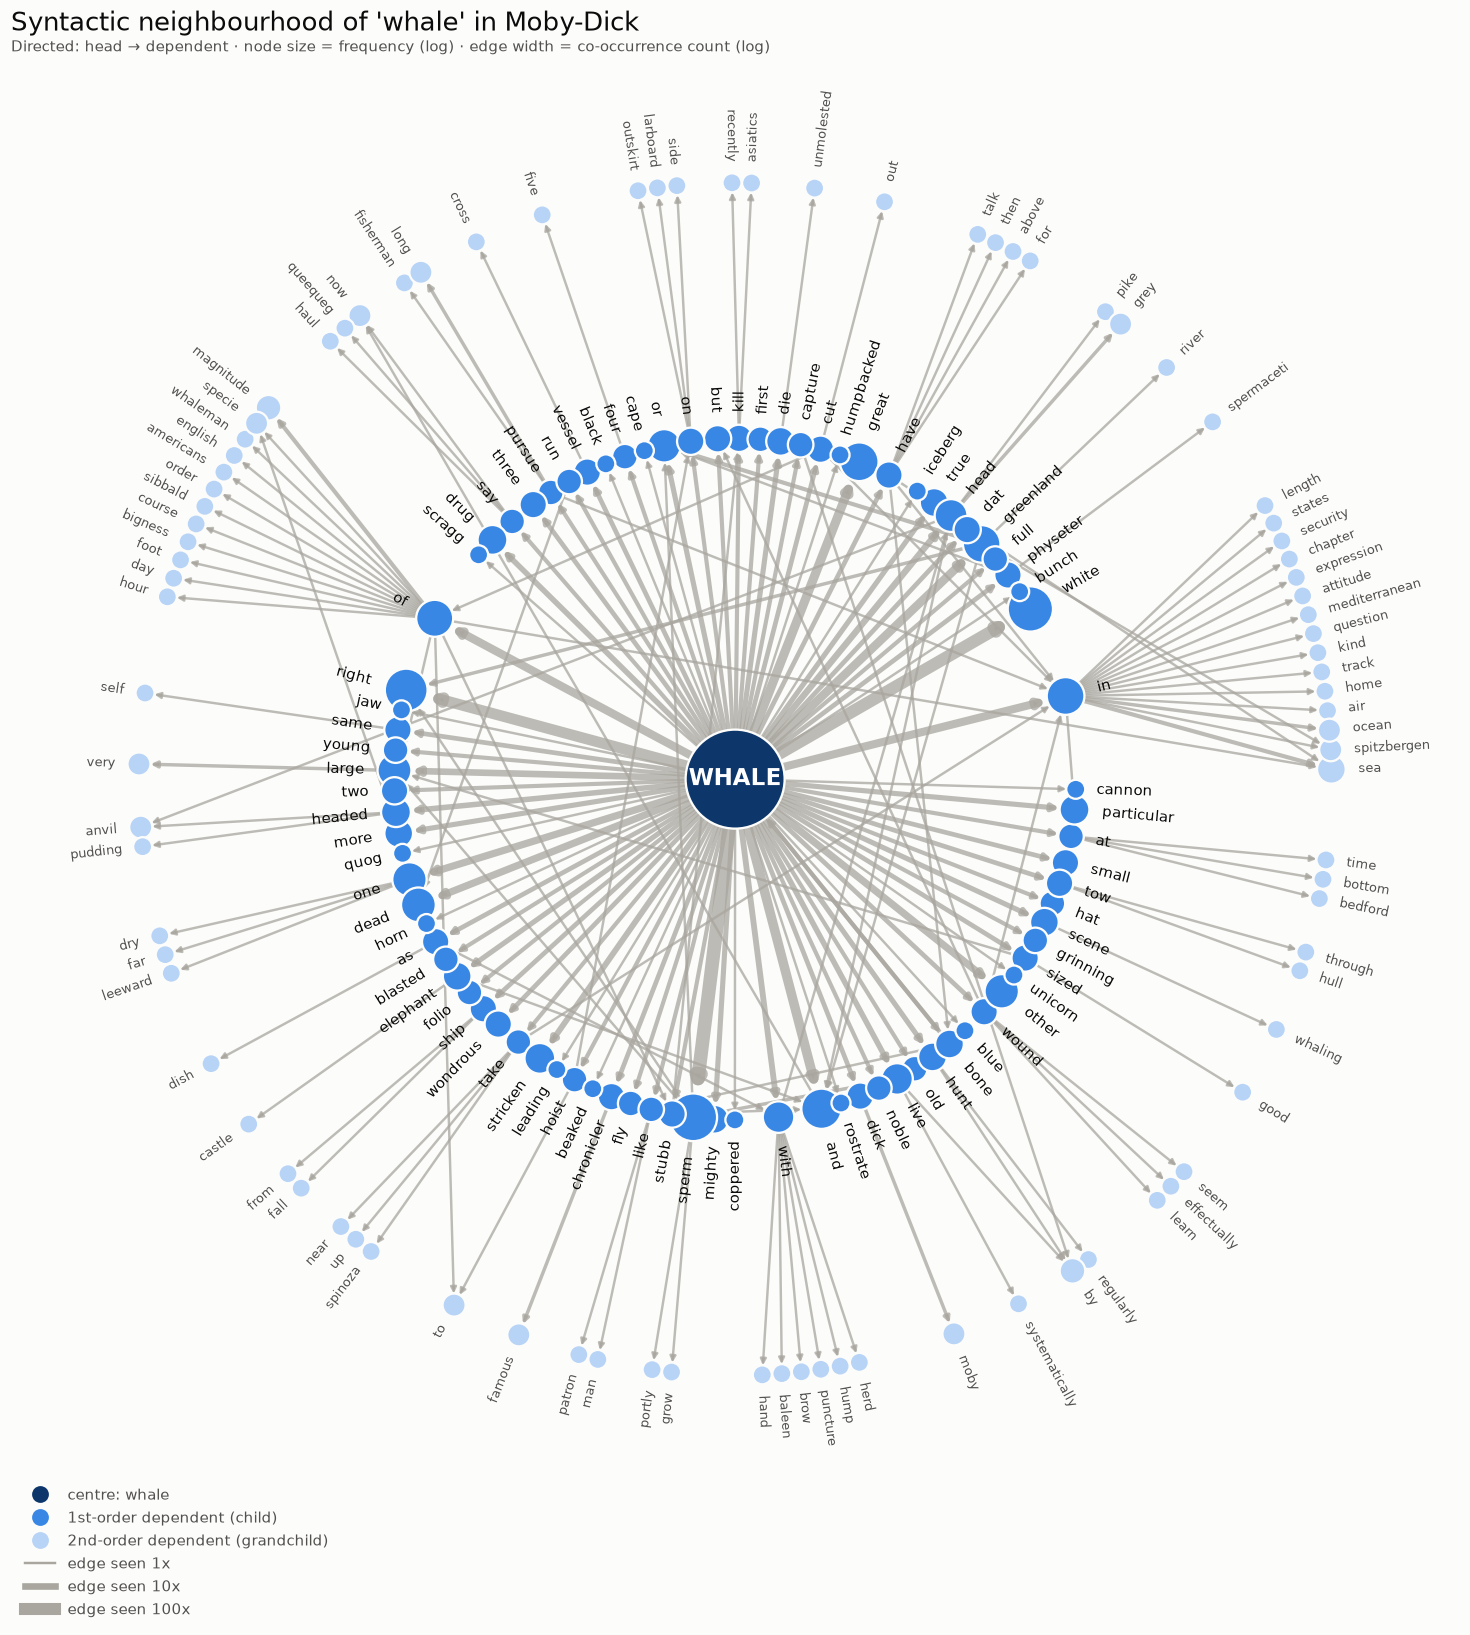

In [10]:
def radial_layout(G, center=CENTER, r1=1.2, r2=2.1):
    # Sunburst-style radial tree: whale at the origin, children on ring 1, grandchildren on ring 2.
    # Every child gets an angular sector proportional to the number of its own dependents (min. 1 slot),
    # and its grandchildren are spread evenly inside that sector, so no part of the ring gets crowded.
    pos = {center: (0.0, 0.0)}
    ring1 = [n for n in G if G.nodes[n]["level"] == 1]
    kids = collections.defaultdict(list)
    for n in G:
        if G.nodes[n]["level"] == 2:
            heads = [h for h in G.predecessors(n) if G.nodes[h]["level"] == 1]
            kids[max(heads, key=lambda h: G[h][n]["weight"])].append(n)
    # big hubs alternate with small leaves around the circle
    by_kids = sorted(ring1, key=lambda n: (-len(kids[n]), -G.nodes[n]["freq"]))
    hubs, leaves = [n for n in by_kids if kids[n]], [n for n in by_kids if not kids[n]]
    # deal the leaves out round-robin (most frequent first), so big leaves end up far apart
    # and place the hubs with a golden-ratio stride, so the biggest hubs are not neighbours either
    H = max(len(hubs), 1)
    stride = max(1, round(H * 0.382))
    while math.gcd(stride, H) != 1:
        stride += 1
    groups = [[] for _ in range(H)]
    for i, h in enumerate(hubs):
        groups[(i * stride) % H].append(h)
    for i, leaf in enumerate(leaves):
        groups[(i * stride) % H].append(leaf)
    order = [n for g in groups for n in g]
    KID = 0.55                       # the outer ring is longer, so a grandchild needs a narrower slot
    slots = {n: max(1, KID * len(kids[n])) for n in order}
    unit, a = 2 * math.pi / sum(slots.values()), 0.0
    for n in order:
        mid = a + unit * slots[n] / 2
        G.nodes[n]["angle"] = mid
        pos[n] = (r1 * math.cos(mid), r1 * math.sin(mid))
        ks = sorted(kids[n], key=lambda m: -G.nodes[m]["freq"])
        for j, kname in enumerate(ks):
            ang = a + unit * slots[n] * (j + 0.5) / len(ks)
            G.nodes[kname]["angle"] = ang
            pos[kname] = (r2 * math.cos(ang), r2 * math.sin(ang))
        a += unit * slots[n]
    G.nodes[center]["angle"] = 0.0
    return pos

def draw_graph(G, pos, node_color, title, fname, legend_handles, subtitle="", label_min_freq=0, scale=1.0, edge_alpha=0.75):
    fig, ax = plt.subplots(figsize=(15, 15), facecolor=SURFACE); ax.set_facecolor(SURFACE)
    w = [G[u][v]["weight"] for u, v in G.edges]
    sizes = [node_size(G, n) * (1 if n == CENTER else scale) for n in G]
    nx.draw_networkx_edges(G, pos, ax=ax, width=[(0.5 + 1.6 * math.log1p(x)) * (1 if scale == 1 else 0.6) for x in w],
                           edge_color="#a8a69e", alpha=edge_alpha, arrows=True, arrowstyle="-|>",
                           arrowsize=8 if scale == 1 else 4, node_size=sizes,
                           connectionstyle="arc3,rad=0.0")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=[node_color[n] for n in G],
                           node_size=sizes, edgecolors=SURFACE, linewidths=1.5 * scale)
    for n, (x, y) in pos.items():
        lvl = G.nodes[n]["level"]
        if lvl == 0:
            ax.text(x, y, n.upper(), ha="center", va="center", fontsize=15, color="white", weight="bold")
            continue
        if G.nodes[n]["freq"] < label_min_freq:
            continue
        # radial labels: written along the spoke, flipped on the left half so they are never upside down
        ang = G.nodes[n]["angle"]; deg = math.degrees(ang) % 360
        left = 90 < deg < 270
        r_node = math.sqrt(node_size(G, n) * scale) / 2 / 72 * 0.5            # approx. marker radius in data units
        off = r_node + 0.03
        ax.text(x + off * math.cos(ang), y + off * math.sin(ang), n,
                rotation=deg - 180 if left else deg, rotation_mode="anchor",
                ha="right" if left else "left", va="center",
                fontsize=10 if lvl == 1 else 8.5, color=INK if lvl == 1 else INK2)
    lim = 2.55
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_title(title, loc="left", fontsize=17, color=INK, pad=16)
    if subtitle:
        ax.text(0, 1.0, subtitle, transform=ax.transAxes, fontsize=10, color=INK2, va="bottom")
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(0, 0.02), frameon=False, fontsize=10, labelcolor=INK2)
    ax.set_aspect("equal"); ax.axis("off")
    plt.tight_layout(); plt.savefig(fname, facecolor=SURFACE, bbox_inches="tight"); plt.show()

def node_size(G, n):
    return 4200 if n == CENTER else 30 + 180 * math.log1p(G.nodes[n]["freq"])

from matplotlib.lines import Line2D
pos = radial_layout(G)
level_color = {n: LEVEL_COLORS[G.nodes[n]["level"]] for n in G}
handles = [Line2D([], [], marker="o", ls="", markersize=11, markerfacecolor=LEVEL_COLORS[i], markeredgecolor="none", label=l)
           for i, l in [(0, "centre: whale"), (1, "1st-order dependent (child)"), (2, "2nd-order dependent (grandchild)")]]
handles += [Line2D([], [], color="#a8a69e", lw=0.5 + 1.6 * math.log1p(k), label=f"edge seen {k}x") for k in (1, 10, 100)]
draw_graph(G, pos, level_color, "Syntactic neighbourhood of 'whale' in Moby-Dick", "figures/03_whale_dependency_graph.png",
           handles, "Directed: head → dependent · node size = frequency (log) · edge width = co-occurrence count (log)")

### The complete graph (all dependencies, no filtering)

The task asks for *all* children and grandchildren around the word, so here is the **full graph** too: all 618 lemmas and 938 edges, with function words included. It uses the same layout and the same encodings. Only words that occur at least 8 times are labelled; otherwise the 600+ labels would overlap. The picture shows the result described in Section 5: a dense ring of 1st-order dependents, most of which have no dependents of their own, and a few hubs (*in, of, and, with, be, have*) that carry almost all of the 2nd level.

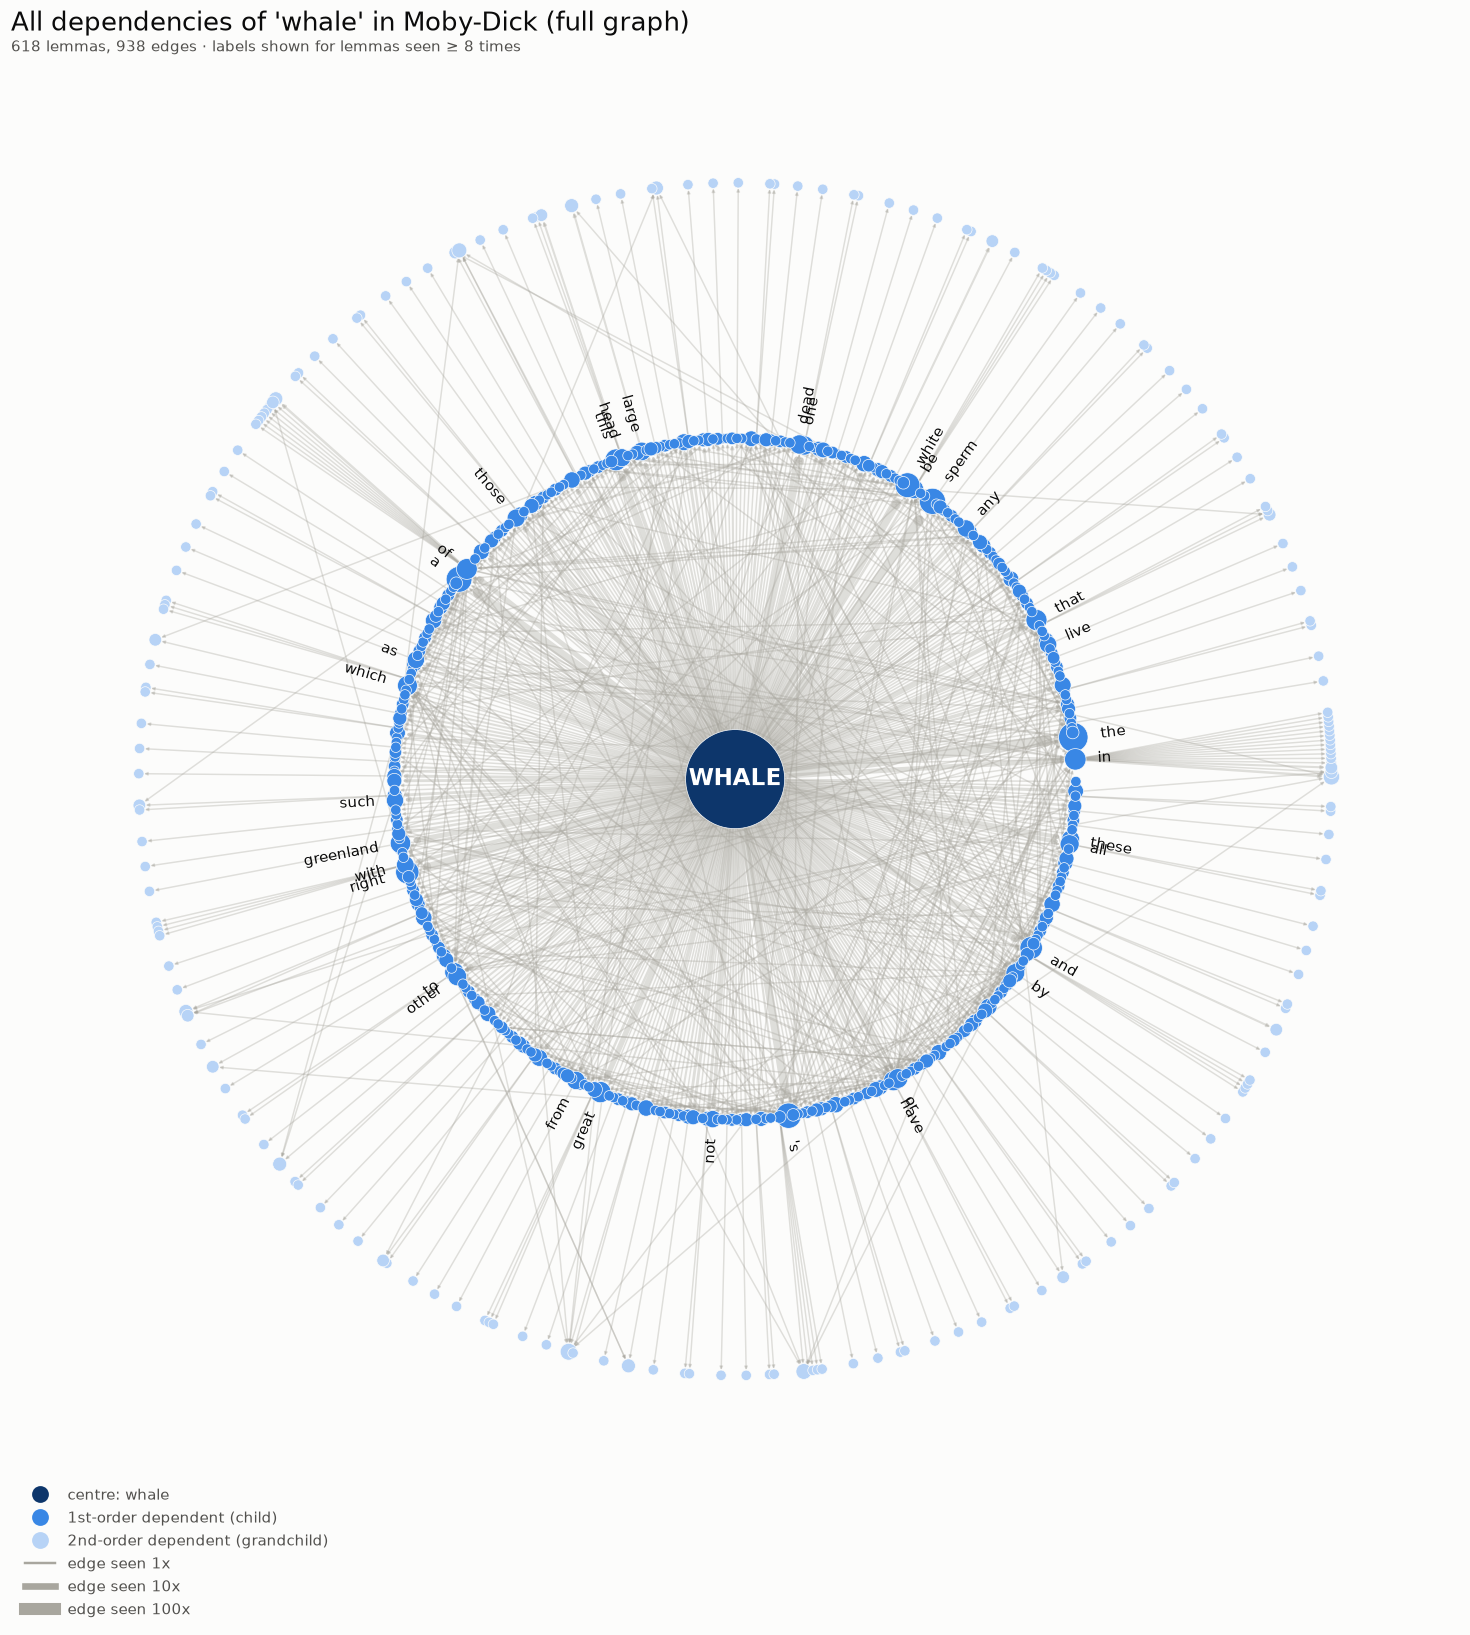

In [11]:
pos_full = radial_layout(G_full, r1=1.2, r2=2.1)
level_color_full = {n: LEVEL_COLORS[G_full.nodes[n]["level"]] for n in G_full}
draw_graph(G_full, pos_full, level_color_full, "All dependencies of 'whale' in Moby-Dick (full graph)",
           "figures/03b_whale_full_graph.png", handles,
           f"{G_full.number_of_nodes()} lemmas, {G_full.number_of_edges()} edges · labels shown for lemmas seen ≥ 8 times",
           label_min_freq=8, scale=0.3, edge_alpha=0.35)

## 5. Network analysis (2 pt)

I analyse the **full graph** (all dependents, including function words), because its numbers do not depend on my filtering choices. For the community picture I use the **content graph**, because its communities are easier to interpret. The measures I compute:

1. **Size and density.** Density = actual edges / possible edges. It shows how "tree-like" or how interconnected the neighbourhood is.
2. **Degree distribution.** Is the network dominated by a few hubs (heavy tail) or are degrees even?
3. **Centrality** (the four measures from class). *Degree centrality*: how many relations a word has. *Closeness*: how close a word is to all others. *Betweenness*: how often a word lies on shortest paths; in this graph it finds the "bridge" words through which *whale* reaches its 2nd-order context. *Eigenvector centrality*: a word is important if its neighbours are important. I also report *out-degree* (how many different dependents a word governs, i.e. syntactic productivity) and *in-degree* (how many different heads a word depends on).
4. **Clustering / transitivity.** A pure dependency tree has no triangles. Triangles appear only when the same lemma is both a child of *whale* and a child of another child (lemma merging). Transitivity shows how much of that overlap there is.
5. **Diameter, average shortest path, connected components, assortativity** (`degree_pearson_correlation_coefficient`): global shape of the network.
6. **Communities**, with the two algorithms from class, on the undirected weighted graph (dependency direction does not matter for "which words hang together"):
   * **greedy modularity** (`greedy_modularity_communities`) merges communities step by step while modularity grows. This is my main method.
   * **Girvan–Newman** (`girvan_newman`) repeatedly removes the edge with the highest betweenness. I take the level of its hierarchy with the highest modularity.

   Modularity Q measures how good a split is: Q > 0.3 usually means a clear community structure. As an extra robustness check (beyond the class material) I also run Louvain, a faster modularity method.

In [12]:
def summary(G, name):
    U = G.to_undirected()
    return pd.Series({
        "nodes": G.number_of_nodes(), "edges": G.number_of_edges(),
        "density (directed)": nx.density(G), "density (undirected)": nx.density(U),
        "mean degree": 2 * U.number_of_edges() / U.number_of_nodes(),
        "max out-degree": max(d for _, d in G.out_degree()),
        "transitivity": nx.transitivity(U), "avg clustering": nx.average_clustering(U),
        "diameter (undirected)": nx.diameter(U) if nx.is_connected(U) else float("nan"),
        "avg shortest path": nx.average_shortest_path_length(U) if nx.is_connected(U) else float("nan"),
        "connected components": nx.number_connected_components(U),
        "assortativity (degree Pearson r)": nx.degree_pearson_correlation_coefficient(U),
    }, name=name)

stats = pd.concat([summary(G_full, "full graph"), summary(G, "content graph")], axis=1)
stats.round(4)

,full graph,content graph
nodes,618.0000,174.0000
edges,938.0000,214.0000
density (directed),0.0025,0.0071
density (undirected),0.0049,0.0142
mean degree,3.0259,2.4483
max out-degree,425.0000,84.0000
transitivity,0.0096,0.0230
avg clustering,0.1696,0.0752
diameter (undirected),4.0000,4.0000
avg shortest path,2.6039,2.9323


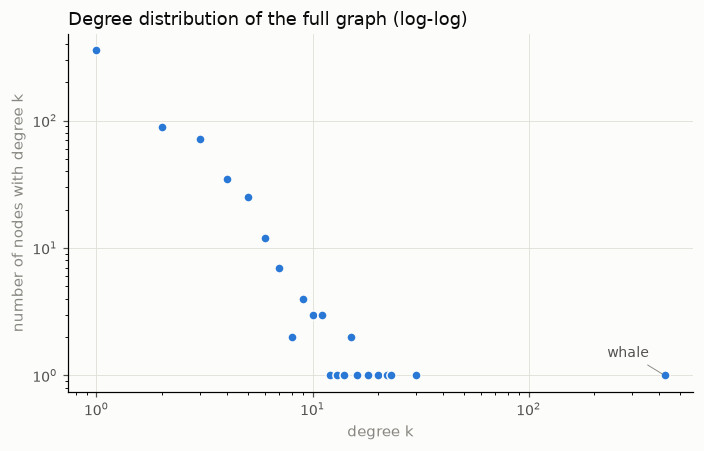

Share of nodes with degree 1 (leaves): 57.4%


In [13]:
# Degree distribution of the full graph (undirected degree), log-log
U_full = G_full.to_undirected()
deg = collections.Counter(d for _, d in U_full.degree())
xs, ys = zip(*sorted(deg.items()))
fig, ax = plt.subplots(figsize=(6.5, 4.2), facecolor=SURFACE); ax.set_facecolor(SURFACE)
ax.scatter(xs, ys, s=36, color=CATEGORICAL[0], edgecolors=SURFACE, linewidths=1, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.annotate("whale", (U_full.degree(CENTER), 1), xytext=(-10, 12), textcoords="offset points",
            ha="right", fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6))
ax.set_title("Degree distribution of the full graph (log-log)", loc="left", color=INK, fontsize=12)
ax.set_xlabel("degree k", color=MUTED); ax.set_ylabel("number of nodes with degree k", color=MUTED)
ax.tick_params(colors=INK2, labelsize=9); ax.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("figures/04_degree_distribution.png", facecolor=SURFACE); plt.show()
share_leaves = sum(1 for _, d in U_full.degree() if d == 1) / U_full.number_of_nodes()
print(f"Share of nodes with degree 1 (leaves): {share_leaves:.1%}")

In [14]:
# Centrality (degree, closeness, betweenness, eigenvector) on the undirected full graph
cent = pd.DataFrame({
    "level": nx.get_node_attributes(G_full, "level"),
    "freq": nx.get_node_attributes(G_full, "freq"),
    "out_degree": dict(G_full.out_degree()),
    "in_degree": dict(G_full.in_degree()),
    "degree_c": nx.degree_centrality(U_full),
    "closeness": nx.closeness_centrality(U_full),
    "betweenness": nx.betweenness_centrality(U_full),
    "eigenvector": nx.eigenvector_centrality(U_full, max_iter=1000),
})
print("Top 5 by each centrality (whale is first everywhere, so it is left out):")
display(pd.DataFrame({m: cent.drop(CENTER).sort_values(m, ascending=False).index[:5]
                      for m in ["degree_c", "closeness", "betweenness", "eigenvector"]}))
print("Top bridge words (betweenness), excluding 'whale':")
display(cent.drop(CENTER).sort_values("betweenness", ascending=False).head(12).round(4))
print("Words that collect the most incoming dependencies (in-degree > 1 means several heads share the dependent):")
display(cent.drop(CENTER).sort_values("in_degree", ascending=False).head(8).round(4))

Top 5 by each centrality (whale is first everywhere, so it is left out):


,degree_c,closeness,betweenness,eigenvector
0,in,in,in,have
1,of,have,of,which
2,have,which,be,in
3,be,be,with,be
4,which,of,descry,the


Top bridge words (betweenness), excluding 'whale':


,level,freq,out_degree,in_degree,degree_c,closeness,betweenness,eigenvector
in,1,32,16,14,0.0486,0.4523,0.0449,0.0619
of,1,25,16,7,0.0373,0.4448,0.0265,0.0560
be,1,14,8,12,0.0324,0.4461,0.0156,0.0598
with,1,9,7,3,0.0162,0.4398,0.0142,0.0397
descry,1,2,10,1,0.0178,0.4413,0.0138,0.0460
take,1,3,9,1,0.0162,0.4445,0.0137,0.0436
head,1,10,6,3,0.0146,0.4385,0.0114,0.0405
have,1,18,9,13,0.0357,0.4514,0.0102,0.0688
kill,1,5,5,3,0.0130,0.4376,0.0098,0.0422
lad,1,1,5,1,0.0097,0.4354,0.0097,0.0360


Words that collect the most incoming dependencies (in-degree > 1 means several heads share the dependent):


,level,freq,out_degree,in_degree,degree_c,closeness,betweenness,eigenvector
which,1,18,0,18,0.0292,0.4474,0.0018,0.0659
the,1,818,0,15,0.0243,0.4407,0.0007,0.0563
in,1,32,16,14,0.0486,0.4523,0.0449,0.0619
and,1,45,1,14,0.0243,0.4423,0.0021,0.0562
by,1,13,1,13,0.0227,0.4401,0.0037,0.0527
have,1,18,9,13,0.0357,0.4514,0.0102,0.0688
to,1,15,3,13,0.0259,0.4445,0.0075,0.0559
that,1,27,0,13,0.0211,0.4423,0.0008,0.0553


**Communities: two variants.** In an *ego network*, i.e. a network built around one focal node, the ego (*whale*) is connected to every 1st-order node by definition. Modularity then always comes out low, because the hub glues everything together. The standard practice in ego-network analysis is therefore to look for communities in the **alter network** as well: the same graph with the ego removed. I run greedy modularity (main method) and Louvain on both variants, and Girvan–Newman on the content graph (it is too slow for the 600-node graph).

In [15]:
def ordered(comms):
    return sorted(map(set, comms), key=lambda c: (-len(c), sorted(c)))

def greedy(U):
    comms = ordered(nx_comm.greedy_modularity_communities(U, weight="weight"))
    return comms, nx_comm.modularity(U, comms, weight="weight")

def louvain(U, seed=42):
    comms = ordered(nx_comm.louvain_communities(U, weight="weight", seed=seed))
    return comms, nx_comm.modularity(U, comms, weight="weight")

def girvan_newman_best(U, max_levels=60):
    # walk down the Girvan–Newman hierarchy and keep the level with the highest modularity
    best, best_q = None, -1
    for level, comms in zip(range(max_levels), nx_comm.girvan_newman(U)):
        q = nx_comm.modularity(U, comms, weight="weight")
        if q > best_q:
            best, best_q = ordered(comms), q
    return best, best_q

rows_q = []
for name, g in [("full graph", G_full), ("content graph", G)]:
    U = g.to_undirected()
    A = U.copy(); A.remove_node(CENTER); A.remove_nodes_from(list(nx.isolates(A)))
    for variant, h in [("with ego (whale)", U), ("alter network (no whale, no isolates)", A)]:
        cm, q = greedy(h)
        row = dict(graph=name, variant=variant, nodes=h.number_of_nodes(),
                   components=nx.number_connected_components(h), communities_greedy=len(cm),
                   Q_greedy=round(q, 3), Q_louvain=round(louvain(h)[1], 3))
        if name == "content graph":                      # Girvan–Newman is slow on the 600-node graph
            row["Q_girvan_newman"] = round(girvan_newman_best(h)[1], 3)
        rows_q.append(row)
display(pd.DataFrame(rows_q))

# Communities of the content alter network (used for the figure)
A = G.to_undirected(); A.remove_node(CENTER)
isolated = sorted(nx.isolates(A), key=lambda n: -G.nodes[n]["freq"]); A.remove_nodes_from(isolated)
comms, Q = greedy(A)
print(f"Content alter network (greedy modularity): {len(comms)} communities, Q = {Q:.3f}; "
      f"{len(isolated)} children of 'whale' have no dependents of their own (isolates), e.g. {', '.join(isolated[:10])}")
for i, c in enumerate(comms[:10]):
    members = sorted(c, key=lambda n: -G.nodes[n]["freq"])
    print(f"  C{i+1} ({len(c):>2}): {', '.join(members[:14])}{' ...' if len(c) > 14 else ''}")

,graph,variant,nodes,components,communities_greedy,Q_greedy,Q_louvain,Q_girvan_newman
0,full graph,with ego (whale),618,1,56,0.233,0.231,NaN
1,full graph,"alter network (no whale, no isolates)",435,37,54,0.745,0.749,NaN
2,content graph,with ego (whale),174,1,20,0.185,0.183,0.150
3,content graph,"alter network (no whale, no isolates)",136,12,23,0.801,0.804,0.786


Content alter network (greedy modularity): 23 communities, Q = 0.801; 37 children of 'whale' have no dependents of their own (isolates), e.g. great, other, stricken, drug, mighty, true, more, wondrous, small, three
  C1 (21): in, particular, sea, have, ocean, home, for, above, talk, mediterranean, expression, chapter, attitude, then ...
  C2 (18): sperm, right, greenland, or, live, hunt, physeter, by, four, capture, spitzbergen, river, spermaceti, five ...
  C3 (15): of, two, cut, magnitude, day, bigness, sibbald, out, americans, foot, english, course, order, whaleman ...
  C4 (11): and, elephant, kill, stubb, say, now, haul, queequeg, recently, asiatics, castle
  C5 (10): with, as, specie, hump, brow, baleen, hand, herd, dish, puncture
  C6 ( 7): white, head, headed, anvil, grey, pike, pudding
  C7 ( 6): on, hoist, to, side, larboard, outskirt
  C8 ( 5): wound, but, effectually, seem, learn
  C9 ( 4): at, bedford, time, bottom
  C10 ( 4): bone, like, man, patron


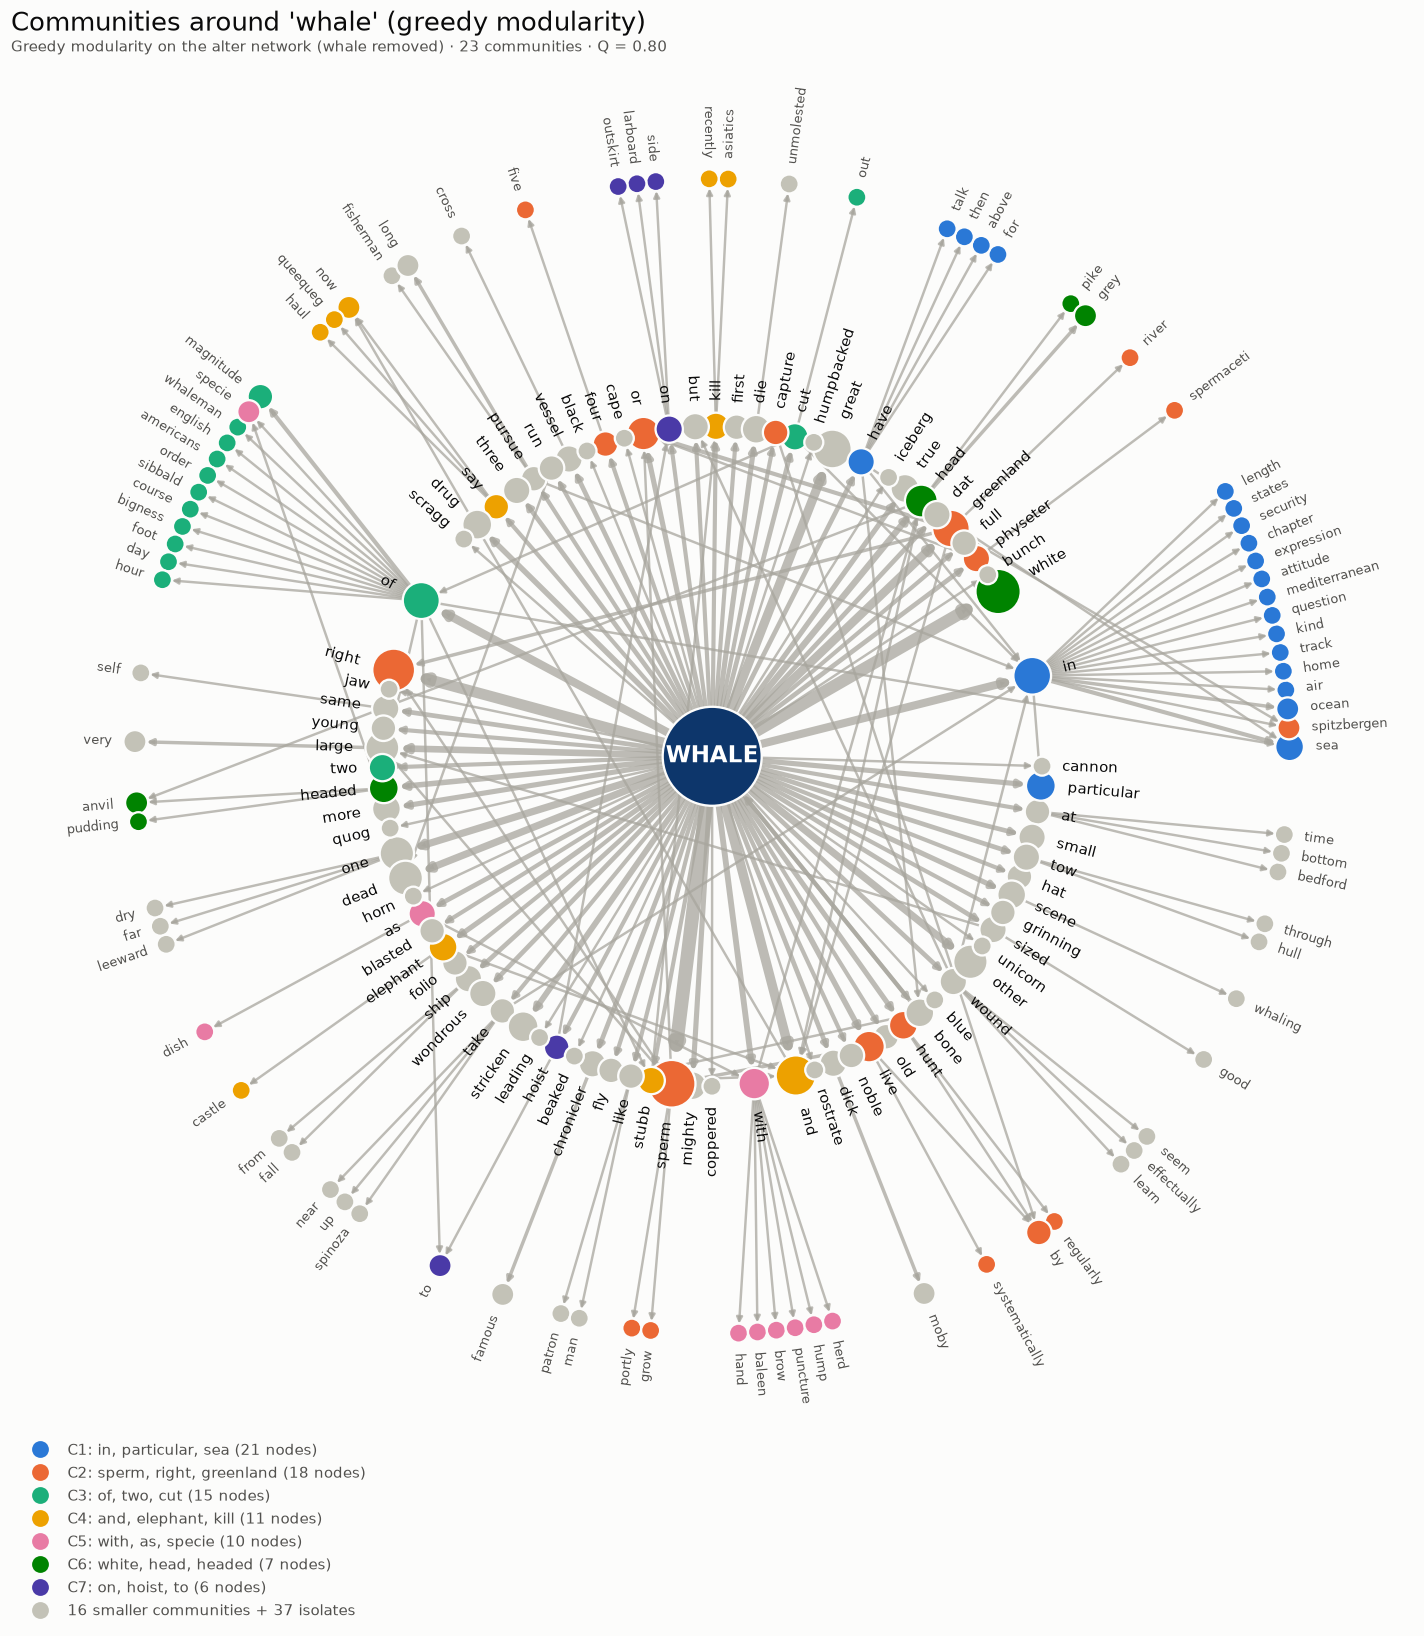

In [16]:
# Same radial layout, coloured by community. The 7 largest communities get the first 7 categorical slots;
# smaller communities and isolates share a neutral grey (colours never cycle).
comm_color = {n: OTHER for n in G}
for i, c in enumerate(comms[:7]):
    for n in c:
        comm_color[n] = CATEGORICAL[i]
comm_color[CENTER] = LEVEL_COLORS[0]
handles_c = []
for i, c in enumerate(comms[:7]):
    lead = sorted(c, key=lambda n: -G.nodes[n]["freq"])[:3]
    handles_c.append(Line2D([], [], marker="o", ls="", markersize=11, markerfacecolor=CATEGORICAL[i],
                            markeredgecolor="none", label=f"C{i+1}: {', '.join(lead)} ({len(c)} nodes)"))
handles_c.append(Line2D([], [], marker="o", ls="", markersize=11, markerfacecolor=OTHER, markeredgecolor="none",
                        label=f"{max(len(comms) - 7, 0)} smaller communities + {len(isolated)} isolates"))
draw_graph(G, pos, comm_color, "Communities around 'whale' (greedy modularity)", "figures/05_whale_communities.png",
           handles_c, f"Greedy modularity on the alter network (whale removed) · {len(comms)} communities · Q = {Q:.2f}")

In [17]:
# Extra (beyond class): k-core, the densest "core" of the full graph (nodes with at least k neighbours inside the core)
core = nx.core_number(nx.Graph(U_full))
kmax = max(core.values())
print(f"Max k-core = {kmax}; its members:", sorted(n for n, k in core.items() if k == kmax))

Max k-core = 4; its members: ['be', 'descry', 'find', 'have', 'in', 'pursue', 'take', 'whale', 'which', 'wound']


### Interpretation of the measures

**Density and shape.** The full graph has 618 nodes and 938 edges, with a density of only **0.0025** (directed) or **0.0049** (undirected). The filtered content graph is also sparse (0.014). *whale* alone governs 425 different lemmas, and 57% of all nodes are leaves (degree 1). Degree assortativity is clearly negative (−0.31): hubs connect to leaves, not to other hubs. Together these numbers describe a **"star of stars"** (hub and spokes). This is what dependency syntax predicts. Every token has exactly one head, so the extracted structure is a forest of small trees. The only extra links come from *lemma merging*: the same lemma (e.g. *the*, *which*, *great*) depends on several different heads.

**Clustering.** Global transitivity is almost zero (0.01), so triangles are very rare. The average local clustering (0.17) is higher only because a few low-degree words are attached both to *whale* and to one of its children. For such a node, a single triangle already gives a clustering of 1.

**Degree distribution.** The distribution is heavy-tailed and roughly linear on the log–log plot: a few hubs and a long tail of leaves. This is the typical Zipf-like pattern of word networks.

**Centrality.** The four centralities from class agree: after *whale* itself, the most central word is the preposition **in** (first by degree, closeness and betweenness). Eigenvector centrality ranks **have, which, in, be** highest. These words form the relative-clause cluster (*the whale which they have ...*), which links to many other well-connected words. Betweenness picks out the *bridges* through which *whale* reaches its 2nd-order context. These are the prepositions **in, of, with**, the verbs **be / have** (heads of relative clauses: *the whale which have ...*) and the noun **head** (*whale's head*). The words with the highest *in-degree* are function words shared by many heads (*which, the, and, by, to, that*). They are the "glue" of the network but carry no content. The **4-core**, the most tightly interconnected group, contains the hunting verbs **pursue, take, descry, find, wound** together with *be, have, which, in*. These are relative clauses about the whale (*the whale which they pursue / wounded*), so the act of whaling forms the densest part of the network.

**Communities.** With *whale* included, modularity stays low (Q ≈ 0.23 on the full graph and 0.19 on the content graph), because the hub glues everything together. In the **alter network** (ego removed), greedy modularity finds a clear structure: **Q = 0.75** (full) and **Q = 0.80** (content). Girvan–Newman (Q = 0.79) and Louvain (Q = 0.80) give almost the same result, so the partition does not depend on the algorithm. The content communities are semantically coherent:

| community | key words | what it is about |
|---|---|---|
| C1 | *in → sea, ocean, air, Mediterranean* | **where** the whale is (location) |
| C2 | *sperm, right, Greenland, physeter, spermaceti, hunt, capture* | **zoology**: species of whale and the whaling industry |
| C3 | *of → magnitude, bigness, foot, hour, day, English, Americans* | **measuring and describing**: size, time, nationality |
| C4 | *and → elephant, Stubb, Queequeg, kill* | **coordination**: whale compared with other giants, and with the crew |
| C5 | *with → hump, baleen, brow, hand, herd* | **anatomy** (whale *with* a hump / baleen) |
| C6 | *white, head(ed), grey* | **appearance**: the white / grey-headed whale |

## 6. Conclusions (1 pt)

Syntactically, *whale* is overwhelmingly a **modified** word. 44% of its children are determiners, 17% are compounds that name species (*sperm, right, Greenland whale*) and 14% are adjectives (*white, great, dead, stricken*). Melville's whale is constantly being **classified and described**. The network is a sparse, disassortative "star of stars" (density ≈ 0.005, almost no triangles). Its communities (greedy modularity on the alter network, Q ≈ 0.8) correspond to distinct ways of talking about the whale: zoological classification, location (*in the sea*), measurement (*of great magnitude*), anatomy (*with a hump*) and appearance (*white*). Meanwhile, the densest core is made of hunting verbs (*pursue, take, wound*). This mirrors the novel's double nature: half natural-history encyclopaedia, half hunting story.

**Limitations.** spaCy's small model was trained on modern English, so 19th-century spellings and archaisms are sometimes mis-lemmatized or mis-parsed (e.g. *species* → *specie*; *drugged whale*, a whale held by a whaling float called a *drugg*, → *drug*; the cook's dialect *dat whale* is left as *dat*). The content-graph thresholds (≥ 3 occurrences) are a readability choice. For this reason all quantitative statements are also reported for the unfiltered full graph.